Задание:
Собрать датасет, проанализировать рынок конкретной отрасли, посчитать метрику и сделать вывод.
Для этого предоставлен реестр всех предпринимателей из ФНС, требуется его подготовить к работе(вас интересуют юридические лица, среднее и малые предприятия, в видах деятельности указывайте 41.20 Строительство жилых и нежилых зданий).
Определите насколько перспективна отрасль строительства с помощью подсчёта EBITA всех компаний по годам.
Но в данной таблице не будут выложены данные, нужные для подсчёта этой метрики, поэтому вам потребуется с этой (https://bo.nalog.gov.ru/)  странички спарсить все нужные данные.
Также вам предстоит построить графики (x=процент роста чистой прибыли компании относительно N-летней давности, у-Количество компаний с таким процентном) *х-целое число, N вы подбирайте на своё усмотрение*. 
Также требуется написать вывод после увиденных графиков.
Затем ознакомьтесь с geopandas. И нанесите топ500 компаний по выручке на карту по месту регистрации.

Применил к исходному файлу ("Реестр_Исходный.xlsx") с данными фильтр и получил нужную таблицу("Фильтр_Реестр_Осн.xlsx") для последующего парсинга.

Проверим содержимое:

In [20]:
import pandas as pd
df_reestr = pd.read_excel("Фильтр_Реестр_Осн.xlsx")

df_reestr.head()

,Единый реестр субъектов малого и среднего предпринимательства по состоянию на 15.04.2024,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,№ п/п,Наименование / ФИО,Тип субъекта,Категория,ОГРН,ИНН,Основной вид деятельности,Регион,Район,Город,...,Дата исключения из реестра,Телефон,E-mail,WWW,Наличие лицензий,"Наличие заключенных договоров, контрактов","Производство инновационной, высокотехнологично...",Участие в программах партнерства,Является социальным предприятием,Среднесписочная численность работников за пред...
2,20,"""КОРПОРАЦИЯ ВИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕ...",Юридическое лицо,Малое предприятие,1025004907080,5038038838,41.20 Строительство жилых и нежилых зданий,50 - Московская область,Пушкино г,NaN,...,NaN,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,36
3,52,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",Юридическое лицо,Среднее предприятие,1025007270551,5027006369,41.20 Строительство жилых и нежилых зданий,50 - Московская область,NaN,г Дзержинский,...,NaN,NaN,NaN,NaN,Да,Нет,Нет,Нет,Нет,201
4,4653,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""777""",Юридическое лицо,Малое предприятие,1021400692048,1414006922,41.20 Строительство жилых и нежилых зданий,77 - г.Москва,NaN,NaN,...,NaN,NaN,NaN,NaN,Да,Нет,Нет,Нет,Нет,35


In [17]:
inn_list = df_reestr["ИНН"].astype(str).tolist()
print("Всего компаний для парсинга:", len(inn_list))
print("Пример первых 5 ИНН:", inn_list[:5])

Всего компаний для парсинга: 8927
Пример первых 5 ИНН: ['5038038838', '5027006369', '1414006922', '3327332190', '7816061297']


Проверка:

In [32]:
import requests
import time
import pandas as pd
import os

session = requests.Session()
session.headers.update({
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
    "Accept": "application/json",
})

def get_org_id(inn: str):
    url = f"https://bo.nalog.gov.ru/advanced-search/organizations/search?query={inn}&page=0"
    r = session.get(url, timeout=10)
    data = r.json()
    if not data.get("content"):
        return None
    return data["content"][0]["id"]

def get_financials(org_id):
    url = f"https://bo.nalog.gov.ru/nbo/organizations/{org_id}/bfo/"
    r = session.get(url, timeout=10)
    return r.json()

def extract_financials(inn, reports):
    rows = []
    for rep in reports:
        fr = rep.get("typeCorrections", [{}])[0].get("correction", {}).get("financialResult", {})
        if not fr:
            continue
        report_year = rep.get("period")

        rows.append({
            "inn": inn,
            "year": report_year,
            "revenue": fr.get("current2110"),
            "profit_from_sales": fr.get("current2200"),
        })
        if report_year:
            rows.append({
                "inn": inn,
                "year": str(int(report_year) - 1),
                "revenue": fr.get("previous2110"),
                "profit_from_sales": fr.get("previous2200"),
            })
    return rows

RESULTS_FILE = "financials_raw.csv"
NOTFOUND_FILE = "not_found.csv"
PROGRESS_FILE = "processed_inn.csv"

if os.path.exists(PROGRESS_FILE):
    processed = set(pd.read_csv(PROGRESS_FILE)["inn"].astype(str).tolist())
else:
    processed = set()

results_buffer = []
not_found_buffer = []
processed_buffer = []

def save_buffers():
    global results_buffer, not_found_buffer, processed_buffer
    if results_buffer:
        df_new = pd.DataFrame(results_buffer)
        df_new.to_csv(RESULTS_FILE, mode="a", index=False,
                       header=not os.path.exists(RESULTS_FILE))
        results_buffer = []
    if not_found_buffer:
        df_nf = pd.DataFrame({"inn": not_found_buffer})
        df_nf.to_csv(NOTFOUND_FILE, mode="a", index=False,
                      header=not os.path.exists(NOTFOUND_FILE))
        not_found_buffer = []
    if processed_buffer:
        df_p = pd.DataFrame({"inn": processed_buffer})
        df_p.to_csv(PROGRESS_FILE, mode="a", index=False,
                     header=not os.path.exists(PROGRESS_FILE))
        processed_buffer = []

total = len(inn_list)
for i, inn in enumerate(inn_list):

    if inn in processed:
        continue

    try:
        org_id = get_org_id(inn)
        if org_id is None:
            not_found_buffer.append(inn)
        else:
            reports = get_financials(org_id)
            rows = extract_financials(inn, reports)
            results_buffer.extend(rows)
    except Exception as e:
        print(f"Ошибка по ИНН {inn}: {e}")

    processed_buffer.append(inn)
    time.sleep(0.3)

    if (i + 1) % 50 == 0:
        save_buffers()
        print(f"Обработано {i + 1} из {total}")

save_buffers()
print("Парсинг завершён")

Парсинг завершён


In [33]:
df_test = pd.read_csv("financials_raw.csv")
df_test.head(20)

,inn,year,revenue,profit_from_sales
0,5038038838,2025,140064.0,355.0
1,5038038838,2024,112540.0,-8789.0
2,5038038838,2024,112540.0,-8789.0
3,5038038838,2023,108966.0,-8093.0
4,5038038838,2023,108966.0,-8093.0
5,5038038838,2022,118633.0,2396.0
6,5038038838,2022,118633.0,2396.0
7,5038038838,2021,184044.0,-5813.0
8,5038038838,2021,184044.0,-5813.0
9,5038038838,2020,303726.0,-102445.0


In [34]:
inn_list = inn_list_backup

import os
for f in ["financials_raw.csv", "not_found.csv", "processed_inn.csv"]:
    if os.path.exists(f):
        os.remove(f)
        print(f"Удалён: {f}")

print("Готово к полному запуску, компаний в очереди:", len(inn_list))

Удалён: financials_raw.csv
Удалён: not_found.csv
Удалён: processed_inn.csv
Готово к полному запуску, компаний в очереди: 8927


Парсинг данных:

In [36]:
import requests
import time
import pandas as pd
import os

session = requests.Session()
session.headers.update({
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
    "Accept": "application/json",
})

def get_org_id(inn: str):
    url = f"https://bo.nalog.gov.ru/advanced-search/organizations/search?query={inn}&page=0"
    r = session.get(url, timeout=10)
    data = r.json()
    if not data.get("content"):
        return None
    return data["content"][0]["id"]

def get_financials(org_id):
    url = f"https://bo.nalog.gov.ru/nbo/organizations/{org_id}/bfo/"
    r = session.get(url, timeout=10)
    return r.json()

def extract_financials(inn, reports):
    rows = []
    for rep in reports:
        fr = rep.get("typeCorrections", [{}])[0].get("correction", {}).get("financialResult", {})
        if not fr:
            continue
        report_year = rep.get("period")

    
        rows.append({
            "inn": inn,
            "year": report_year,
            "revenue": fr.get("current2110"),
            "profit_from_sales": fr.get("current2200"),
        })
        
        if report_year:
            rows.append({
                "inn": inn,
                "year": str(int(report_year) - 1),
                "revenue": fr.get("previous2110"),
                "profit_from_sales": fr.get("previous2200"),
            })
    return rows


RESULTS_FILE = "financials_raw.csv"
NOTFOUND_FILE = "not_found.csv"
PROGRESS_FILE = "processed_inn.csv"

if os.path.exists(PROGRESS_FILE):
    processed = set(pd.read_csv(PROGRESS_FILE)["inn"].astype(str).tolist())
else:
    processed = set()

results_buffer = []
not_found_buffer = []
processed_buffer = []

def save_buffers():
    global results_buffer, not_found_buffer, processed_buffer
    if results_buffer:
        df_new = pd.DataFrame(results_buffer)
        df_new.to_csv(RESULTS_FILE, mode="a", index=False,
                       header=not os.path.exists(RESULTS_FILE))
        results_buffer = []
    if not_found_buffer:
        df_nf = pd.DataFrame({"inn": not_found_buffer})
        df_nf.to_csv(NOTFOUND_FILE, mode="a", index=False,
                      header=not os.path.exists(NOTFOUND_FILE))
        not_found_buffer = []
    if processed_buffer:
        df_p = pd.DataFrame({"inn": processed_buffer})
        df_p.to_csv(PROGRESS_FILE, mode="a", index=False,
                     header=not os.path.exists(PROGRESS_FILE))
        processed_buffer = []

total = len(inn_list)
for i, inn in enumerate(inn_list):

    if inn in processed:         
        continue

    try:
        org_id = get_org_id(inn)
        if org_id is None:
            not_found_buffer.append(inn)
        else:
            reports = get_financials(org_id)
            rows = extract_financials(inn, reports)
            results_buffer.extend(rows)
    except Exception as e:
        print(f"Ошибка по ИНН {inn}: {e}")

    processed_buffer.append(inn)
    time.sleep(0.3)

    
    if (i + 1) % 50 == 0:
        save_buffers()
        print(f"Обработано {i + 1} из {total}")


save_buffers()
print("Парсинг завершён")

Обработано 200 из 8927
Обработано 250 из 8927
Обработано 300 из 8927
Обработано 350 из 8927
Обработано 400 из 8927
Обработано 450 из 8927
Обработано 500 из 8927
Обработано 550 из 8927
Обработано 600 из 8927
Обработано 650 из 8927
Обработано 700 из 8927
Обработано 750 из 8927
Обработано 800 из 8927
Обработано 850 из 8927
Обработано 900 из 8927
Обработано 950 из 8927
Обработано 1000 из 8927
Обработано 1050 из 8927
Обработано 1100 из 8927
Обработано 1150 из 8927
Обработано 1200 из 8927
Обработано 1250 из 8927
Обработано 1300 из 8927
Обработано 1350 из 8927
Обработано 1400 из 8927
Обработано 1450 из 8927
Обработано 1500 из 8927
Обработано 1550 из 8927
Обработано 1600 из 8927
Обработано 1650 из 8927
Обработано 1700 из 8927
Обработано 1750 из 8927
Обработано 1800 из 8927
Обработано 1850 из 8927
Обработано 1900 из 8927
Обработано 1950 из 8927
Обработано 2000 из 8927
Обработано 2050 из 8927
Обработано 2100 из 8927
Обработано 2150 из 8927
Обработано 2200 из 8927
Обработано 2250 из 8927
Обработа

Что получилось в итоге парсинга:

In [23]:
import pandas as pd

df_result = pd.read_csv("financials_raw.csv")
df_notfound = pd.read_csv("not_found.csv")

print("Строк с финансовыми данными:", len(df_result))
print("Уникальных компаний с данными:", df_result["inn"].nunique())
print("Не найдено на сайте:", len(df_notfound), "из", 8927)
print()
df_result.head(10)

Строк с финансовыми данными: 80474
Уникальных компаний с данными: 8841
Не найдено на сайте: 85 из 8927



,inn,year,revenue,profit_from_sales
0,5027006369,2025,1287757.0,774484.0
1,5027006369,2024,429496.0,10148.0
2,5027006369,2024,429496.0,10148.0
3,5027006369,2023,1565001.0,710983.0
4,5027006369,2023,1565001.0,710983.0
5,5027006369,2022,683396.0,24207.0
6,5027006369,2022,683396.0,24207.0
7,5027006369,2021,584219.0,30016.0
8,5027006369,2021,584219.0,30016.0
9,5027006369,2020,566014.0,42513.0


In [38]:
df_clean = df_result.dropna(subset=["revenue", "profit_from_sales"], how="all")
df_clean = df_clean.drop_duplicates(subset=["inn", "year"], keep="first")

print("После очистки дублей строк:", len(df_clean))

После очистки дублей строк: 47640


In [2]:
import pandas as pd

df_reestr = pd.read_excel("Фильтр_Реестр_Осн.xlsx", header=2)
print(df_reestr.columns.tolist())

['№ п/п', 'Наименование / ФИО', 'Тип субъекта', 'Категория', 'ОГРН', 'ИНН', 'Основной вид деятельности', 'Регион', 'Район', 'Город', 'Населенный пункт', 'Вновь созданный', 'Дата включения в реестр', 'Дата исключения из реестра', 'Телефон', 'E-mail', 'WWW', 'Наличие лицензий', 'Наличие заключенных договоров, контрактов', 'Производство инновационной, высокотехнологичной продукции', 'Участие в программах партнерства', 'Является социальным предприятием', 'Среднесписочная численность работников за предшествующий календарный год']


In [4]:
df_clean["inn"] = df_clean["inn"].astype(str)

df_full = df_clean.merge(
    df_reestr_str[["ИНН", "Наименование / ФИО", "Категория", "Регион"]],
    left_on="inn", right_on="ИНН", how="left"
)
df_full.to_csv("dataset_final.csv", index=False)
df_full.head(10)

,inn,year,revenue,profit_from_sales,ИНН,Наименование / ФИО,Категория,Регион
0,5027006369,2025,1287757.0,774484.0,5027006369,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",Среднее предприятие,50 - Московская область
1,5027006369,2024,429496.0,10148.0,5027006369,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",Среднее предприятие,50 - Московская область
2,5027006369,2023,1565001.0,710983.0,5027006369,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",Среднее предприятие,50 - Московская область
3,5027006369,2022,683396.0,24207.0,5027006369,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",Среднее предприятие,50 - Московская область
4,5027006369,2021,584219.0,30016.0,5027006369,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",Среднее предприятие,50 - Московская область
5,5027006369,2020,566014.0,42513.0,5027006369,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",Среднее предприятие,50 - Московская область
6,1414006922,2025,1927383.0,32715.0,1414006922,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""777""",Малое предприятие,77 - г.Москва
7,1414006922,2024,1107569.0,80971.0,1414006922,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""777""",Малое предприятие,77 - г.Москва
8,1414006922,2023,1002486.0,30999.0,1414006922,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""777""",Малое предприятие,77 - г.Москва
9,1414006922,2022,986540.0,55171.0,1414006922,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""777""",Малое предприятие,77 - г.Москва


In [5]:
print("Строк в df_clean:", len(df_clean))
print("Строк после merge (df_full):", len(df_full))
print("Строк, где не нашлось совпадение в реестре (Категория пустая):", df_full["Категория"].isna().sum())

Строк в df_clean: 47640
Строк после merge (df_full): 47640
Строк, где не нашлось совпадение в реестре (Категория пустая): 0


Посчитаем метрику по годам:

In [6]:
ebit_by_year = df_full.groupby("year").agg(
    total_ebit=("profit_from_sales", "sum"),
    avg_ebit=("profit_from_sales", "mean"),
    median_ebit=("profit_from_sales", "median"),
    total_revenue=("revenue", "sum"),
    companies_count=("profit_from_sales", "count"),
).reset_index().sort_values("year")

ebit_by_year["ebit_growth_%"] = ebit_by_year["total_ebit"].pct_change() * 100
ebit_by_year["revenue_growth_%"] = ebit_by_year["total_revenue"].pct_change() * 100
ebit_by_year["margin_%"] = ebit_by_year["total_ebit"] / ebit_by_year["total_revenue"] * 100

ebit_by_year

,year,total_ebit,avg_ebit,median_ebit,total_revenue,companies_count,ebit_growth_%,revenue_growth_%,margin_%
0,2020,79408745.0,15353.585654,4349.0,1.996935e+09,5172,NaN,NaN,3.976531
1,2021,80234653.0,15259.538418,3851.0,2.189392e+09,5258,1.040072,9.637586,3.664701
2,2022,104737731.0,19795.450954,3843.0,2.214565e+09,5291,30.539271,1.149808,4.729494
3,2023,137019477.0,27934.653823,4969.0,2.547823e+09,4905,30.821506,15.048440,5.377904
4,2024,138675031.0,33839.685456,5347.5,2.678232e+09,4098,1.208262,5.118437,5.177858
5,2025,131793265.0,35051.400266,4150.0,2.633509e+09,3760,-4.962513,-1.669841,5.004473


По данным показателям таблицы можно заметить, что с 2020 по 2024 год суммарная и средняя прибыль компаний отрасли устойчиво росли, при повышении рентабельности продаж с 4% до 5%. Однако доли прибыльных компаний снижались, что возможно указывает на то, что прибыль концетрировалась у ограниченного круга крупных и финансово устойчивых предпринимателей. 

Доля прибыльных компаний по годам:

In [7]:
df_full["is_profitable"] = df_full["profit_from_sales"] > 0
profitable_share = df_full.groupby("year")["is_profitable"].mean() * 100
profitable_share

year
2020    51.836735
2021    48.223653
2022    45.261457
2023    44.614625
2024    38.775782
2025    36.326708
Name: is_profitable, dtype: float64

Загрузим данные и удалим дубли:

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("dataset_final.csv")
print("Строк до очистки:", len(df))
df.head()

Строк до очистки: 47640


,inn,year,revenue,profit_from_sales,ИНН,Наименование / ФИО,Категория,Регион
0,5027006369,2025,1287757.0,774484.0,5027006369,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",Среднее предприятие,50 - Московская область
1,5027006369,2024,429496.0,10148.0,5027006369,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",Среднее предприятие,50 - Московская область
2,5027006369,2023,1565001.0,710983.0,5027006369,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",Среднее предприятие,50 - Московская область
3,5027006369,2022,683396.0,24207.0,5027006369,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",Среднее предприятие,50 - Московская область
4,5027006369,2021,584219.0,30016.0,5027006369,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",Среднее предприятие,50 - Московская область


In [9]:
df = df.drop_duplicates(subset=["inn", "year"], keep="first")

df = df.dropna(subset=["profit_from_sales"])

print("Строк после очистки:", len(df))
print("Уникальных компаний:", df["inn"].nunique())

Строк после очистки: 28484
Уникальных компаний: 5982


Отформатируем таблицу, чтобы развернуть таблицу так, что компании были строками, а годы — столбцами:

In [10]:
pivot = df.pivot_table(index="inn", columns="year", values="profit_from_sales", aggfunc="first")

print("Форма таблицы:", pivot.shape)
pivot.head()

Форма таблицы: (5982, 6)


year,2020,2021,2022,2023,2024,2025
inn,,,,,,
101009232,3410.0,3656.0,19175.0,22025.0,18372.0,42531.0
105008695,2353.0,-7324.0,8574.0,2096.0,41233.0,64075.0
105008744,7177.0,6045.0,5006.0,1.0,0.0,NaN
105027747,20663.0,68060.0,24221.0,53865.0,34346.0,15975.0
105037625,7113.0,11427.0,-367.0,461.0,8436.0,-1063.0


Возьмём только компании, у которых в базовом году была реальная и положительная прибыль — тогда процент роста читается однозначно:

In [11]:
def growth_series(pivot, year_old, year_new):

    sub = pivot[[year_old, year_new]].dropna()
    
    sub = sub[sub[year_old] > 0]
    
    growth = (sub[year_new] - sub[year_old]) / sub[year_old] * 100
    
    return growth.round().astype(int)

Почитаем рост для двух показателей: N1 и N4 (для понимания устойчивости показателей)

In [12]:
growth_n1 = growth_series(pivot, 2023, 2024)

growth_n4 = growth_series(pivot, 2020, 2024)

print("N=1: компаний в выборке —", len(growth_n1))
print("N=4: компаний в выборке —", len(growth_n4))

N=1: компаний в выборке — 3002
N=4: компаний в выборке — 2924


Функция для построения графиков:

In [20]:
def plot_growth(growth, title, lo=-100, hi=300):

    total = len(growth)
    below = (growth < lo).sum()
    above = (growth > hi).sum()
    
    growth_visible = growth[(growth >= lo) & (growth <= hi)]
    
    counts = growth_visible.value_counts().sort_index()
    
    fig, ax = plt.subplots(figsize=(13, 6))
    ax.bar(counts.index, counts.values, width=1.0, color="#3b6ea5")
    ax.axvline(0, color="red", linestyle="--", linewidth=1, alpha=0.7)
    
    ax.set_xlabel("Рост прибыли от продаж, % ")
    ax.set_ylabel("Количество компаний")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)
    
    median = np.median(growth)
    ax.text(0.98, 0.95,
            f"Компаний на графике: {len(growth_visible)} из {total}\n"
            f"Медиана: {median:.0f}%\n"
            f"< {lo}%: {below} комп.  |  > {hi}%: {above} комп.",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=10, bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    
    plt.tight_layout()
    plt.show()

Графики:

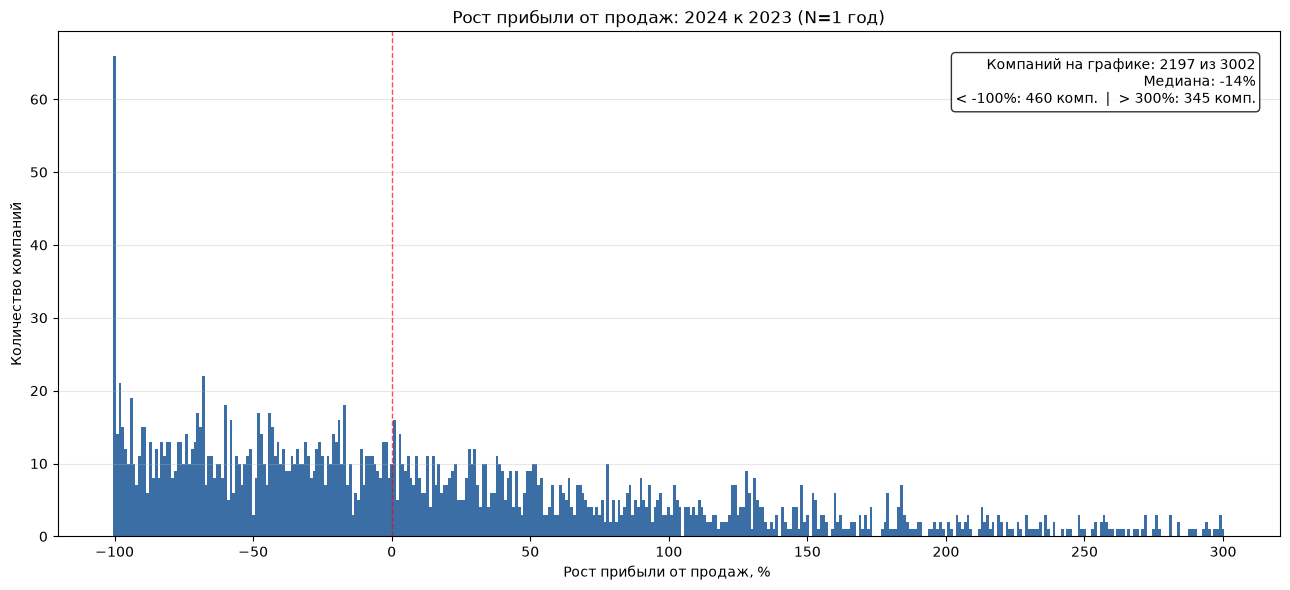

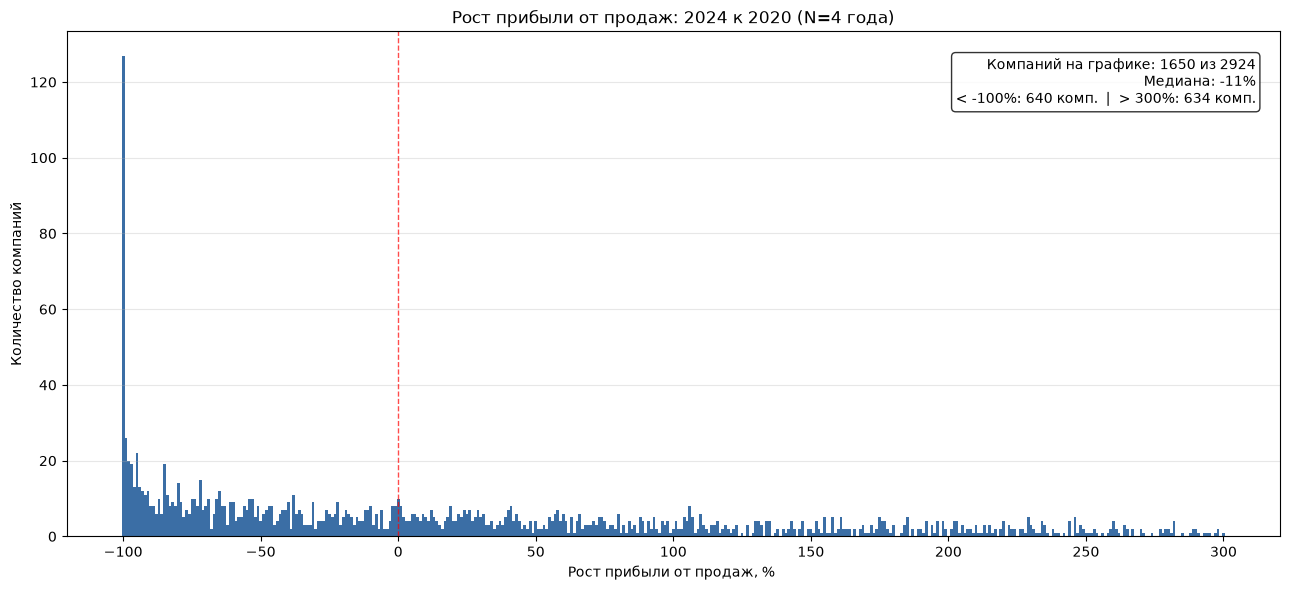

In [21]:
plot_growth(growth_n1, "Рост прибыли от продаж: 2024 к 2023 (N=1 год)")
plot_growth(growth_n4, "Рост прибыли от продаж: 2024 к 2020 (N=4 года)")

Сводная статистика:

In [19]:
def growth_summary(growth, label):
    n = len(growth)
    print(f"{label}, всего компаний: {n}")
    print(f"Выросли (>0%):            {(growth > 0).mean()*100:.1f}%")
    print(f"Снизили прибыль (<0%):    {(growth < 0).mean()*100:.1f}%")
    print(f"Ушли в убыток (<=-100%):  {(growth <= -100).mean()*100:.1f}%")
    print(f"Выросли более чем в 2 раза (>100%): {(growth > 100).mean()*100:.1f}%")
    print()

growth_summary(growth_n1, "N=1 (2023 - 2024)")
growth_summary(growth_n4, "N=4 (2020 - 2024)")

N=1 (2023 - 2024), всего компаний: 3002
Выросли (>0%):            45.5%
Снизили прибыль (<0%):    54.2%
Ушли в убыток (<=-100%):  17.5%
Выросли более чем в 2 раза (>100%): 23.9%

N=4 (2020 - 2024), всего компаний: 2924
Выросли (>0%):            47.7%
Снизили прибыль (<0%):    51.9%
Ушли в убыток (<=-100%):  26.2%
Выросли более чем в 2 раза (>100%): 34.2%



Медианная компания в выборке не растёт, а теряет прибыль: как при показателе N1 (то есть за год), как и при показателе N4 (за 4 года) медиана роста отрицательна (−14% и −11% соответсвенно), доля компаний со снижением прибыли превышает половину (54,2% и 51,9%).
Проблема разовой не является, она только увеличивается со временем, при увеличении интервала времени - увеличивается число компаний, теряющих позиции прибыльности.
При этом доля тех, кто резко нарастил прибыль, также возрастает: с 23,9% за год до 34,2% за 4 года.
Данный вывод согласуется с более ранним, где было указано, что суммарная и средняя прибыль по отрасли росли, при этом доля прибыльных компаний снижалась.
Теперь на уровне отдельных компаний можно заметить, что рост общей прибыли выполняется не засчет всей отрасли равномерно, а конкретно отдельной группой компаний.

Проверим данные:

In [26]:
import re
import time
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
 
df = pd.read_csv("dataset_final.csv")
df = df.drop_duplicates(subset=["inn", "year"], keep="first")
 
latest = df.sort_values("year").groupby("inn", as_index=False).last()
 
top500 = latest.sort_values("revenue", ascending=False).head(500).copy()
 
top500["region_code"] = top500["Регион"].str.extract(r"^(\d+)").astype(float)
top500["region_name"] = top500["Регион"].str.extract(r"-\s*(.+)$")[0].str.strip()
 
print(top500[["inn", "Наименование / ФИО", "revenue", "region_name"]].head())

             inn                                 Наименование / ФИО  \
3933  5401304044  ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "ПРОМ...   
6179  7702681515   ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "ЭРБЕК"   
3820  5257145631  ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "СПЕЦ...   
2855  4004021545  ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "ОРГ-...   
6293  7705989107  ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "СПК-...   

         revenue            region_name  
3933  18261572.0  Новосибирская область  
6179  14902058.0               г.Москва  
3820  12406715.0  Нижегородская область  
2855  11677648.0      Калужская область  
6293  10800142.0               г.Москва  


In [30]:
regions_geo = gpd.read_file("gadm41_RUS_1.json")

In [31]:
print(regions_geo.columns.tolist())
regions_geo.head()

['GID_1', 'GID_0', 'COUNTRY', 'NAME_1', 'VARNAME_1', 'NL_NAME_1', 'TYPE_1', 'ENGTYPE_1', 'CC_1', 'HASC_1', 'ISO_1', 'geometry']


,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
0,RUS.1_1,RUS,Russia,Adygey,Adygea|Adygeya|Adygheya|Republic,РеспубликаАдыгея,Respublika,Republic,NA,RU.AD,NA,"MULTIPOLYGON (((40.3872 44.6721, 40.375 44.642..."
1,RUS.2_1,RUS,Russia,Altay,AltayskiyKray,Алтайскийкрай,Kray,Territory,NA,RU.AL,NA,"MULTIPOLYGON (((82.7466 50.949, 82.7307 50.947..."
2,RUS.3_1,RUS,Russia,Amur,AmurskayaOblast,Амурскаяобласть,Oblast,Region,NA,RU.AM,NA,"MULTIPOLYGON (((130.503 48.8565, 130.4885 48.8..."
3,RUS.4_1,RUS,Russia,Arkhangel'sk,Arcangelo|Archangel|Archangelsk|,Архангельскаяобласть,Oblast,Region,NA,RU.AR,NA,"MULTIPOLYGON (((44.5125 60.932, 44.3058 60.952..."
4,RUS.5_1,RUS,Russia,Astrakhan',Astrachan|AstrakhanskayaOblast,Астраханскаяобласть,Oblast,Region,NA,RU.AS,NA,"MULTIPOLYGON (((47.8749 45.5692, 47.8498 45.55..."


Нанесём ТОП-500 компаний по выручке на карту по месту регистрации:

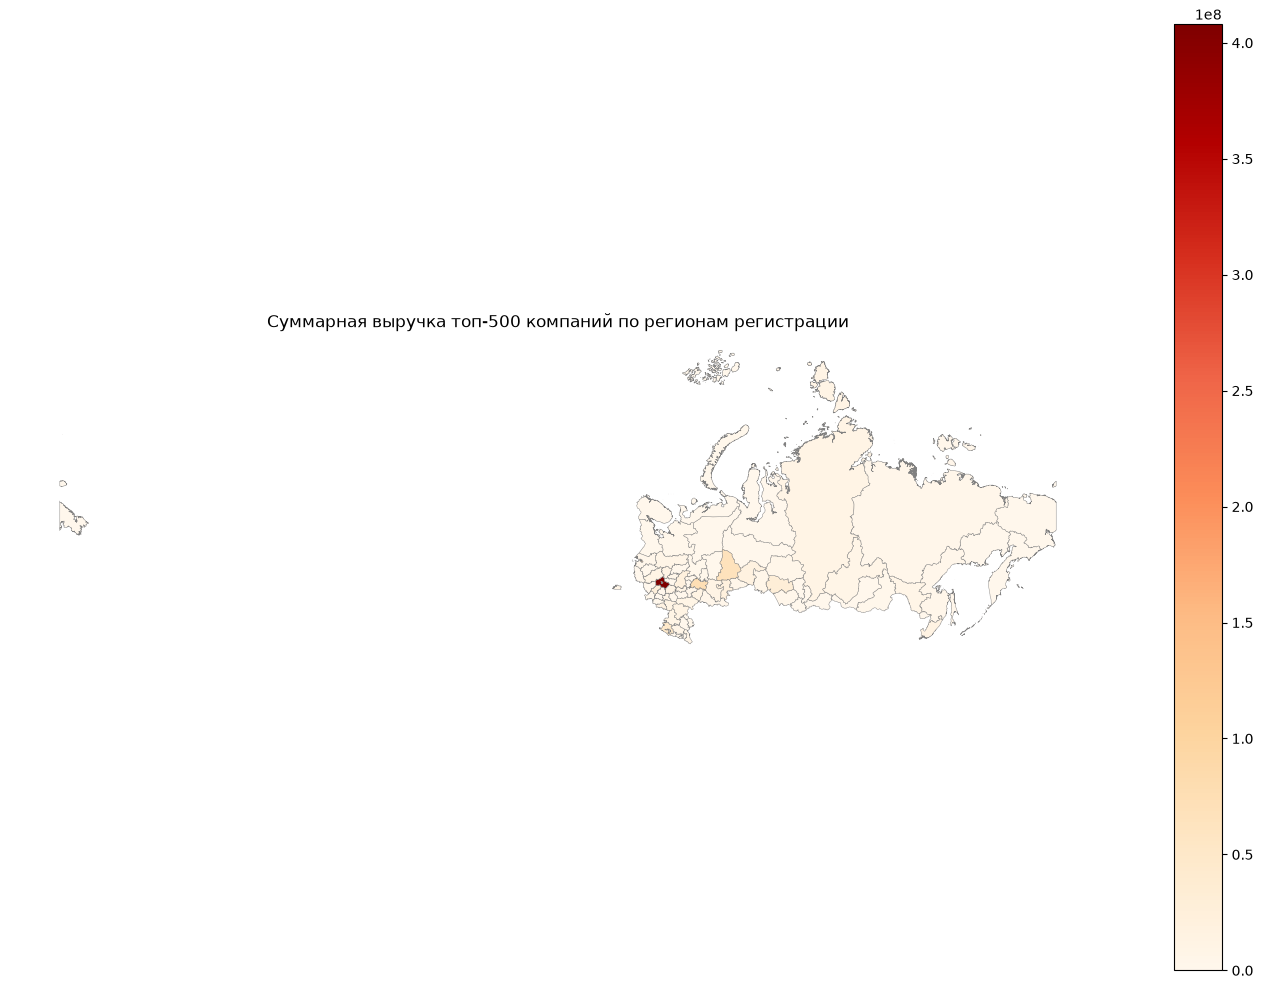

In [43]:
import re
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

df = pd.read_csv("dataset_final.csv")
df = df.drop_duplicates(subset=["inn", "year"], keep="first")

latest = df.sort_values("year").groupby("inn", as_index=False).last()
top500 = latest.sort_values("revenue", ascending=False).head(500).copy()

top500["region_code"] = top500["Регион"].str.extract(r"^(\d+)").astype(float)
top500["region_name"] = top500["Регион"].str.extract(r"-\s*(.+)$")[0].str.strip()

def norm_name(s):
    s = str(s).lower()
    s = s.replace("ё", "е")
    s = re.sub(r"\(.*?\)", "", s)     
    s = re.sub(r"^г\.?\s*", "", s)  
    s = re.sub(r"[\s\-'.]", "", s)     
    return s

top500["name_key"] = top500["region_name"].apply(norm_name)

regions_geo = gpd.read_file("gadm41_RUS_1.json")
regions_geo["name_key"] = regions_geo["NL_NAME_1"].apply(norm_name)

manual_fix_gadm = {
    "Moskva": "москва",
    "CityofSt.Petersburg": "санктпетербург",
}
mask = regions_geo["NAME_1"].isin(manual_fix_gadm)
regions_geo.loc[mask, "name_key"] = regions_geo.loc[mask, "NAME_1"].map(manual_fix_gadm)

region_revenue = (
    top500.groupby("name_key", as_index=False)["revenue"]
    .sum()
    .rename(columns={"revenue": "revenue_sum"})
)

merged = regions_geo.merge(region_revenue, on="name_key", how="left")
merged["revenue_sum"] = merged["revenue_sum"].fillna(0)

fig, ax = plt.subplots(figsize=(14, 10))
merged.to_crs(epsg=3857).plot(
    column="revenue_sum",
    cmap="OrRd",
    linewidth=0.3,
    edgecolor="grey",
    legend=True,
    ax=ax,
)
ax.set_title("Суммарная выручка топ-500 компаний по регионам регистрации")
ax.axis("off")
plt.tight_layout()
plt.savefig("photo_top500.png", dpi=150)
plt.show()

Таким образом, цвет заливки региона является показателем суммарной выручки, шкала из чисел также соответствует заливке и определяется засчёт численного показателя, где наивысшей мерой является 4 * (10 ** 8) = 400 млн.